# Predicción del NBA All-Star con Machine Learning

**Tesis de Máster en Ciencia de Datos — Tilburg University**

Este notebook presenta el flujo principal del proyecto: construcción del dataset, preparación de datos,
entrenamiento y optimización de modelos, evaluación y análisis estadístico de las discrepancias entre
predicciones y selecciones observadas.

> Versión preparada para portfolio. El notebook académico original se conserva por separado.


## 1. Construcción e integración del dataset

El proyecto parte de fuentes históricas separadas y construye un dataset analítico jugador–temporada,
integrando rendimiento NBA y selecciones All-Star.


In [20]:
# Cargamos el nba_dataset


In [21]:
import pandas as pd

# Asegúrate de usar doble backslash en Windows para la ruta del archivo
file_path = "data/nba_data.csv"

# Cargar el dataset de NBA desde el archivo CSV
nba_dataset = pd.read_csv(file_path)

# Ahora puedes trabajar con 'nba_dataset' como un DataFrame de pandas


In [22]:
#Open it is a pd dataframe
nba_dataset = nba_dataset.dropna(how='all') 
pd.DataFrame(nba_dataset)


,Unnamed: 0,Names,Team_abbreviation,Age,Player_height,Player_weight,College,Country,Draft_year,Draft_round,...,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,Season,BMI
0,0,Randy Livingston,HOU,22,193.04,94.800728,Louisiana State,USA,1996,2,...,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996,25.439997
1,1,Gaylon Nickerson,WAS,28,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996,23.748109
2,2,George Lynch,VAN,26,203.20,103.418976,North Carolina,USA,1993,1,...,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996,25.046833
3,3,George McCloud,LAL,30,203.20,102.058200,Florida State,USA,1989,1,...,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996,24.717270
4,4,George Zidek,DEN,23,213.36,119.748288,UCLA,USA,1995,1,...,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996,26.305303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12839,12839,Joel Embiid,PHI,29,213.36,127.005760,Kansas,Cameroon,2014,1,...,10.2,4.2,8.8,0.057,0.243,0.370,0.655,0.233,2022,27.899564
12840,12840,John Butler Jr.,POR,20,213.36,86.182480,Florida State,USA,Undrafted,Undrafted,...,0.9,0.6,-16.1,0.012,0.065,0.102,0.411,0.066,2022,18.931847
12841,12841,John Collins,ATL,25,205.74,102.511792,Wake Forest,USA,2017,1,...,6.5,1.2,-0.2,0.035,0.180,0.168,0.593,0.052,2022,24.217893
12842,12842,Jericho Sims,NYK,24,208.28,113.398000,Texas,USA,2021,2,...,4.7,0.5,-6.7,0.117,0.175,0.074,0.780,0.044,2022,26.140281


In [23]:
#Cargar all star dataset con nombres ya limpios y darle una fila por temporada a cada jugador


In [24]:
import pandas as pd

# Asegúrate de proporcionar la ruta completa al archivo en tu sistema local
file_path = 'data/nba_all_stars_1996_2023.xlsx'

# Cargar el dataset de All-Star desde el archivo Excel
all_star_df = pd.read_excel(file_path, engine='openpyxl')

# "Despivotar" las columnas de años en filas
all_star_melted = all_star_df.melt(id_vars=['Names', 'Appereances', 'Seasons'],
                                   var_name='Year', value_name='All_Star')

# Convertir el nombre de las columnas de año a un formato de año limpio
all_star_melted['Year'] = all_star_melted['Year'].str.extract('(\d+)').astype(int)

# Opcionalmente, renombrar columnas para facilitar el merging posterior
all_star_melted.rename(columns={'Names': 'name', 'Year': 'season'}, inplace=True)

# Suponiendo que ya has cargado tu 'nba_dataset' en otro DataFrame llamado nba_dataset, realizar el merge
# El DataFrame nba_dataset debería tener columnas 'name' y 'season' que coincidan con las del all_star_melted
# dataset_final = pd.merge(nba_dataset, all_star_melted, on=['name', 'season'], how='left')

# El dataset_final ahora contendrá las filas con los nombres de los jugadores, las temporadas y si fueron seleccionados para el All-Star
# Guardar el DataFrame final a un nuevo archivo Excel si es necesario
# dataset_final.to_excel('C:\\Users\\Alejandro\\Desktop\\MASTER\\Thesis\\nba_dataset_final.xlsx', index=False, engine='openpyxl')


In [25]:
pd.DataFrame(all_star_df)


,Names,Appereances,Seasons,All-Star 1996 YES/NO,All-Star 1997 YES/NO,All-Star 1998 YES/NO,All-Star 2000 YES/NO,All-Star 2001 YES/NO,All-Star 2002 YES/NO,All-Star 2003 YES/NO,...,All-Star 2013 YES/NO,All-Star 2014 YES/NO,All-Star 2015 YES/NO,All-Star 2016 YES/NO,All-Star 2017 YES/NO,All-Star 2018 YES/NO,All-Star 2019 YES/NO,All-Star 2020 YES/NO,All-Star 2021 YES/NO,All-Star 2022 YES/NO
0,Shawn Kemp,3,"1996, 1997, 1998",1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Mitch Richmond,3,"1996, 1997, 1998",1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Dikembe Mutombo,6,"1996, 1997, 1998, 2000, 2001, 2002",1,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,Tim Hardaway,2,"1997, 1998",0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Reggie Miller,2,"1998, 2000",0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,Darius Garland,1,2022,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
178,Dejounte Murray,1,2022,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
179,Fred VanVleet,1,2022,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
180,Andrew Wiggins,1,2022,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [26]:
pd.DataFrame(all_star_melted)


,name,Appereances,Seasons,season,All_Star
0,Shawn Kemp,3,"1996, 1997, 1998",1996,1
1,Mitch Richmond,3,"1996, 1997, 1998",1996,1
2,Dikembe Mutombo,6,"1996, 1997, 1998, 2000, 2001, 2002",1996,1
3,Tim Hardaway,2,"1997, 1998",1996,0
4,Reggie Miller,2,"1998, 2000",1996,0
...,...,...,...,...,...
4727,Darius Garland,1,2022,2022,1
4728,Dejounte Murray,1,2022,2022,1
4729,Fred VanVleet,1,2022,2022,1
4730,Andrew Wiggins,1,2022,2022,1


In [27]:
all_star_melted.rename(columns={'name': 'Names'}, inplace=True)
all_star_melted.rename(columns={'Seasons': 'Selected in'}, inplace=True)
all_star_melted.rename(columns={'season': 'Season'}, inplace=True)
pd.DataFrame(all_star_melted)

all_star = pd.DataFrame(all_star_melted)


In [28]:
pd.DataFrame(all_star_melted)


,Names,Appereances,Selected in,Season,All_Star
0,Shawn Kemp,3,"1996, 1997, 1998",1996,1
1,Mitch Richmond,3,"1996, 1997, 1998",1996,1
2,Dikembe Mutombo,6,"1996, 1997, 1998, 2000, 2001, 2002",1996,1
3,Tim Hardaway,2,"1997, 1998",1996,0
4,Reggie Miller,2,"1998, 2000",1996,0
...,...,...,...,...,...
4727,Darius Garland,1,2022,2022,1
4728,Dejounte Murray,1,2022,2022,1
4729,Fred VanVleet,1,2022,2022,1
4730,Andrew Wiggins,1,2022,2022,1


In [29]:
def check_match(row):
    # Check if the 'Names' and 'Season' of the current row match any row in all_star_melted
    if any((all_star_melted['Names'] == row['Names']) & (all_star_melted['Season'] == row['Season'])):
        return 1
    else:
        return 0

# Apply the function to each row in nba_data to create the new column
nba_dataset['selected_yes_or_no'] = nba_dataset.apply(check_match, axis=1)

# Display the updated DataFrame
print(nba_dataset)
pd.DataFrame(nba_dataset)


       Unnamed: 0             Names Team_abbreviation  Age  Player_height  \
0               0  Randy Livingston               HOU   22         193.04   
1               1  Gaylon Nickerson               WAS   28         190.50   
2               2      George Lynch               VAN   26         203.20   
3               3    George McCloud               LAL   30         203.20   
4               4      George Zidek               DEN   23         213.36   
...           ...               ...               ...  ...            ...   
12839       12839       Joel Embiid               PHI   29         213.36   
12840       12840   John Butler Jr.               POR   20         213.36   
12841       12841      John Collins               ATL   25         205.74   
12842       12842      Jericho Sims               NYK   24         208.28   
12843       12843    JaMychal Green               GSW   33         205.74   

       Player_weight                College   Country Draft_year Draft_roun

,Unnamed: 0,Names,Team_abbreviation,Age,Player_height,Player_weight,College,Country,Draft_year,Draft_round,...,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,Season,BMI,selected_yes_or_no
0,0,Randy Livingston,HOU,22,193.04,94.800728,Louisiana State,USA,1996,2,...,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996,25.439997,0
1,1,Gaylon Nickerson,WAS,28,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996,23.748109,0
2,2,George Lynch,VAN,26,203.20,103.418976,North Carolina,USA,1993,1,...,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996,25.046833,0
3,3,George McCloud,LAL,30,203.20,102.058200,Florida State,USA,1989,1,...,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996,24.717270,0
4,4,George Zidek,DEN,23,213.36,119.748288,UCLA,USA,1995,1,...,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996,26.305303,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12839,12839,Joel Embiid,PHI,29,213.36,127.005760,Kansas,Cameroon,2014,1,...,4.2,8.8,0.057,0.243,0.370,0.655,0.233,2022,27.899564,1
12840,12840,John Butler Jr.,POR,20,213.36,86.182480,Florida State,USA,Undrafted,Undrafted,...,0.6,-16.1,0.012,0.065,0.102,0.411,0.066,2022,18.931847,0
12841,12841,John Collins,ATL,25,205.74,102.511792,Wake Forest,USA,2017,1,...,1.2,-0.2,0.035,0.180,0.168,0.593,0.052,2022,24.217893,0
12842,12842,Jericho Sims,NYK,24,208.28,113.398000,Texas,USA,2021,2,...,0.5,-6.7,0.117,0.175,0.074,0.780,0.044,2022,26.140281,0


In [30]:
def count_ones(dataframe, column_name='selected_yes_or_no'):
    # Count the number of 1's in the specified column
    count = (dataframe[column_name] == 1).sum()
    return count

num_ones = count_ones(nba_dataset)
print(f"Number of 1's in 'selected_yes_or_no': {num_ones}")


Number of 1's in 'selected_yes_or_no': 2045


In [31]:
# Renaming the column 'selected_yes_or_no' to 'selected yes or no'
nba_dataset.rename(columns={'selected_yes_or_no': 'selected yes or no'}, inplace=True)

# Display the DataFrame to confirm the change
print(nba_dataset)


       Unnamed: 0             Names Team_abbreviation  Age  Player_height  \
0               0  Randy Livingston               HOU   22         193.04   
1               1  Gaylon Nickerson               WAS   28         190.50   
2               2      George Lynch               VAN   26         203.20   
3               3    George McCloud               LAL   30         203.20   
4               4      George Zidek               DEN   23         213.36   
...           ...               ...               ...  ...            ...   
12839       12839       Joel Embiid               PHI   29         213.36   
12840       12840   John Butler Jr.               POR   20         213.36   
12841       12841      John Collins               ATL   25         205.74   
12842       12842      Jericho Sims               NYK   24         208.28   
12843       12843    JaMychal Green               GSW   33         205.74   

       Player_weight                College   Country Draft_year Draft_roun

In [32]:
pd.DataFrame(nba_dataset)


,Unnamed: 0,Names,Team_abbreviation,Age,Player_height,Player_weight,College,Country,Draft_year,Draft_round,...,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,Season,BMI,selected yes or no
0,0,Randy Livingston,HOU,22,193.04,94.800728,Louisiana State,USA,1996,2,...,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996,25.439997,0
1,1,Gaylon Nickerson,WAS,28,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996,23.748109,0
2,2,George Lynch,VAN,26,203.20,103.418976,North Carolina,USA,1993,1,...,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996,25.046833,0
3,3,George McCloud,LAL,30,203.20,102.058200,Florida State,USA,1989,1,...,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996,24.717270,0
4,4,George Zidek,DEN,23,213.36,119.748288,UCLA,USA,1995,1,...,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996,26.305303,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12839,12839,Joel Embiid,PHI,29,213.36,127.005760,Kansas,Cameroon,2014,1,...,4.2,8.8,0.057,0.243,0.370,0.655,0.233,2022,27.899564,1
12840,12840,John Butler Jr.,POR,20,213.36,86.182480,Florida State,USA,Undrafted,Undrafted,...,0.6,-16.1,0.012,0.065,0.102,0.411,0.066,2022,18.931847,0
12841,12841,John Collins,ATL,25,205.74,102.511792,Wake Forest,USA,2017,1,...,1.2,-0.2,0.035,0.180,0.168,0.593,0.052,2022,24.217893,0
12842,12842,Jericho Sims,NYK,24,208.28,113.398000,Texas,USA,2021,2,...,0.5,-6.7,0.117,0.175,0.074,0.780,0.044,2022,26.140281,0


## 2. Modelado y optimización

Se comparan **Logistic Regression, Decision Tree y Random Forest**.  
La selección de hiperparámetros utiliza **Grid Search** y validación cruzada de **10 folds**.
La partición final utilizada en la tesis es 70% entrenamiento, 15% validación y 15% test.


### Random Forest


In [45]:
#RF 70-15-15 with grid validation k=10 and test

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report

# Assuming nba_dataset is your DataFrame and has been previously loaded and preprocessed

# Handling missing values separately for numeric and categorical columns
numeric_columns = ['Age', 'Player_height', 'Player_weight', 'ast', 'net_rating', 'pts', 'usg_pct', 'reb']
categorical_columns = ['College', 'Draft_round', 'Draft_number']

# Impute numeric columns with mean
numeric_imputer = SimpleImputer(strategy='mean')
nba_dataset[numeric_columns] = numeric_imputer.fit_transform(nba_dataset[numeric_columns])

# Encode categorical variables
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    nba_dataset[col] = nba_dataset[col].fillna('Missing')  # Filling missing values with a placeholder
    nba_dataset[col] = le.fit_transform(nba_dataset[col])
    label_encoders[col] = le

# Define features and target
X = nba_dataset[['Age', 'Player_height', 'Player_weight', 'College', 'Draft_round', 'ast', 'net_rating', 'pts', 'Draft_number', 'usg_pct', 'reb']]
y = nba_dataset['selected yes or no']

# Splitting the dataset into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)  # 70% training, 30% temp
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 15% validation, 15% test

# Define the Random Forest model
random_forest = RandomForestClassifier(random_state=42)

# Set up the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'max_features': ['auto', 'sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Set up the GridSearchCV with k-fold cross-validation (k=10)
kf = KFold(n_splits=10, random_state=42, shuffle=True)
grid_search = GridSearchCV(estimator=random_forest, param_grid=param_grid, cv=kf, scoring='accuracy', n_jobs=-1)

# Fit the GridSearchCV on the validation set
grid_search.fit(X_val, y_val)

# Get the best parameters and the best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters found: {best_params}")
print(f"Best cross-validation score: {best_score:.2f}")

# Train the final model with the best parameters on the entire training set
final_model = RandomForestClassifier(**best_params, random_state=42)
final_model.fit(X_train, y_train)

# Predict the test set results
y_pred = final_model.predict(X_test)

# Evaluate the model on the test set
accuracy = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

c:\Users\Alejandro\OneDrive\Attachments\lib\site-packages\sklearn\ensemble\_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Best parameters found: {'max_depth': 20, 'max_features': 'auto', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validation score: 0.91


c:\Users\Alejandro\OneDrive\Attachments\lib\site-packages\sklearn\ensemble\_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Test set accuracy: 0.93
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1636
           1       0.83      0.68      0.75       291

    accuracy                           0.93      1927
   macro avg       0.89      0.83      0.85      1927
weighted avg       0.93      0.93      0.93      1927



### Logistic Regression


In [48]:
#LR 70-15-15 with grid validation k=10 and test

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.impute import SimpleImputer

# Assuming log_nba_dataset is your DataFrame and has been previously loaded and preprocessed

# Encoding categorical columns
label_encoders = {}
categorical_columns = ['College', 'Draft_round', 'Draft_number']
for col in categorical_columns:
    le = LabelEncoder()
    log_nba_dataset[col] = le.fit_transform(log_nba_dataset[col].astype(str))
    label_encoders[col] = le

# Handling missing values
imputer = SimpleImputer(strategy='mean')
log_nba_dataset[categorical_columns + ['Age', 'Player_height', 'Player_weight', 'ast', 'net_rating', 'pts', 'usg_pct', 'reb']] = imputer.fit_transform(log_nba_dataset[categorical_columns + ['Age', 'Player_height', 'Player_weight', 'ast', 'net_rating', 'pts', 'usg_pct', 'reb']])

# Splitting the data into features and target
X = log_nba_dataset[['Age', 'Player_height', 'Player_weight', 'College', 'Draft_round', 'ast', 'net_rating', 'pts', 'Draft_number', 'usg_pct', 'reb']]
y = log_nba_dataset['selected yes or no']

# Scaling the data (recommended for Logistic Regression)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Splitting the dataset into training (70%), validation (15%), and testing (15%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)  # 70% training, 30% temp
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 15% validation, 15% test

# Setting up hyperparameter grid for tuning
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],  # Regularization strength
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']  # Algorithm to use in the optimization problem
}

# Creating the Logistic Regression model
logistic_model = LogisticRegression(random_state=42, max_iter=1000)

# Set up the GridSearchCV with k-fold cross-validation (k=10)
kf = KFold(n_splits=10, random_state=42, shuffle=True)
grid_search = GridSearchCV(estimator=logistic_model, param_grid=param_grid, cv=kf, scoring='accuracy', n_jobs=-1)

# Fit the GridSearchCV on the validation set
grid_search.fit(X_val, y_val)

# Best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters found: {best_params}")
print(f"Best cross-validation score: {best_score:.2f}")

# Train the final model with the best parameters on the entire training set
final_model = LogisticRegression(**best_params, random_state=42, max_iter=1000)
final_model.fit(X_train, y_train)

# Predicting the test set results
y_pred = final_model.predict(X_test)

# Evaluating the model on the test set
accuracy = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

Best parameters found: {'C': 0.01, 'solver': 'newton-cg'}
Best cross-validation score: 0.90
Test set accuracy: 0.90
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1636
           1       0.75      0.53      0.62       291

    accuracy                           0.90      1927
   macro avg       0.83      0.75      0.78      1927
weighted avg       0.89      0.90      0.89      1927



### Decision Tree


In [51]:
#DT 70-15-15 with grid validation k=10 and test
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.impute import SimpleImputer

# Assuming nba_dataset is your DataFrame and has been previously loaded and preprocessed

# Encoding categorical columns
label_encoders = {}
categorical_columns = ['College', 'Draft_round', 'Draft_number']
for col in categorical_columns:
    le = LabelEncoder()
    nba_dataset[col] = le.fit_transform(nba_dataset[col].astype(str))
    label_encoders[col] = le

# Handling missing values
imputer = SimpleImputer(strategy='mean')
nba_dataset[categorical_columns + ['Age', 'Player_height', 'Player_weight', 'ast', 'net_rating', 'pts', 'usg_pct', 'reb']] = imputer.fit_transform(nba_dataset[categorical_columns + ['Age', 'Player_height', 'Player_weight', 'ast', 'net_rating', 'pts', 'usg_pct', 'reb']])

# Splitting the data into features and target
X = nba_dataset[[ 'Age', 'Player_height', 'Player_weight', 'College', 'Draft_round', 'ast', 'net_rating', 'pts', 'Draft_number', 'usg_pct', 'reb']]
y = nba_dataset['selected yes or no']

# Splitting the dataset into training (70%), validation (15%), and testing (15%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)  # 70% training, 30% temp
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 15% validation, 15% test

# Setting up parameters grid for grid search
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

# Creating the Decision Tree model
decision_tree = DecisionTreeClassifier(random_state=42)

# Setting up the GridSearchCV with k-fold cross-validation (k=10)
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(decision_tree, param_grid, cv=kf, scoring='accuracy', n_jobs=-1, verbose=1)

# Training the model using grid search on the validation set
grid_search.fit(X_val, y_val)

# Best model
best_tree = grid_search.best_estimator_

# Print the best parameters and cross-validation score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.2f}")

# Training the final model with the best parameters on the entire training set
final_model = DecisionTreeClassifier(**grid_search.best_params_, random_state=42)
final_model.fit(X_train, y_train)

# Predicting the test set results
y_pred = final_model.predict(X_test)

# Evaluating the model on the test set
accuracy = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

Fitting 10 folds for each of 108 candidates, totalling 1080 fits
Best parameters found: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best cross-validation score: 0.88
Test set accuracy: 0.90
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1636
           1       0.69      0.56      0.62       291

    accuracy                           0.90      1927
   macro avg       0.81      0.76      0.78      1927
weighted avg       0.89      0.90      0.89      1927



## 3. Evaluación de modelos

Se inspeccionan matrices de confusión y curvas de aprendizaje para complementar la accuracy global,
especialmente por el desbalance entre selecciones All-Star y no selecciones.


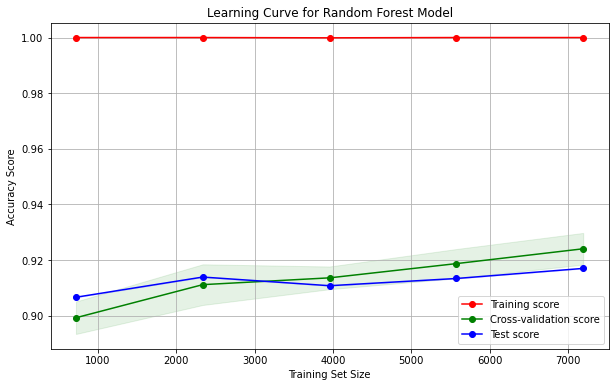

In [46]:
#Graph for Random Forest performance and confusion matrix

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Assuming 'nba_dataset' is prepared and preprocessed, with missing values handled and categorical variables encoded

# Define features and target
X = nba_dataset[['Age', 'Player_height', 'Player_weight', 'College', 'Draft_round', 'ast', 'net_rating', 'pts', 'Draft_number', 'usg_pct', 'reb']]
y = nba_dataset['selected yes or no']

# Split the data into training, validation, and test sets
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1765, random_state=42)  # 0.1765 x 0.85 = 0.15

# Create the model - Random Forest in this case
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Define training sizes and perform learning curve analysis
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=model,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,
    scoring='accuracy'
)

# Calculate mean and standard deviation for training set scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

# Calculate mean and standard deviation for validation set scores
validation_mean = np.mean(validation_scores, axis=1)
validation_std = np.std(validation_scores, axis=1)

# Calculate test scores for each training size
test_scores = []
for train_size in train_sizes:
    model.fit(X_train[:train_size], y_train[:train_size])
    test_scores.append(model.score(X_test, y_test))

test_mean = np.array(test_scores)
test_std = np.zeros_like(test_mean)  # Assuming no std deviation for test set scores

# Plot the learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, validation_mean, 'o-', color="g", label="Cross-validation score")
plt.plot(train_sizes, test_mean, 'o-', color="b", label="Test score")

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="r", alpha=0.1)
plt.fill_between(train_sizes, validation_mean - validation_std, validation_mean + validation_std, color="g", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="b", alpha=0.1)

plt.title("Learning Curve for Random Forest Model")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()


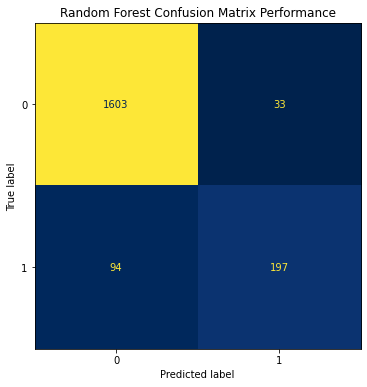

In [47]:
#rf confusion matrix

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Provided values
# True labels
y_true_rf = np.array([0]*1636 + [1]*291)

# Predicted labels based on the confusion matrix
# Assuming confusion matrix for Random Forest based on provided precision and recall
# TN, FP, FN, TP
tn_rf = int(0.98 * 1636)
fp_rf = 1636 - tn_rf
tp_rf = int(0.68 * 291)
fn_rf = 291 - tp_rf

y_pred_rf = np.array([0]*tn_rf + [1]*fp_rf + [0]*fn_rf + [1]*tp_rf)

# Compute the confusion matrix for Random Forest
cm_rf = confusion_matrix(y_true_rf, y_pred_rf)

# Display the confusion matrix with colorblind-friendly colors
fig, ax = plt.subplots(figsize=(8, 6))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(ax=ax, cmap='cividis', colorbar=False)
plt.title("Random Forest Confusion Matrix Performance")
plt.show()

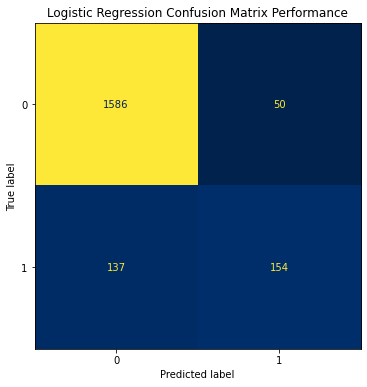

In [49]:
#lr confusion matrix

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Provided values
# True labels
y_true = np.array([0]*1636 + [1]*291)

# Predicted labels based on the confusion matrix
# Assuming confusion matrix for logistic regression based on provided precision and recall
# TN, FP, FN, TP
tn = int(0.97 * 1636)
fp = 1636 - tn
tp = int(0.53 * 291)
fn = 291 - tp

y_pred = np.array([0]*tn + [1]*fp + [0]*fn + [1]*tp)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display the confusion matrix with colorblind-friendly colors
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap='cividis', colorbar=False)
plt.title("Logistic Regression Confusion Matrix Performance")
plt.show()


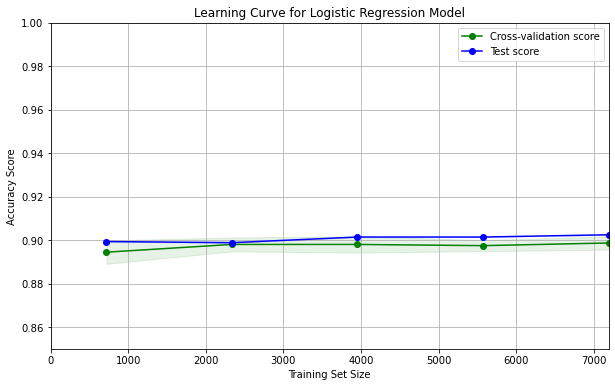

In [50]:
# Graph for LR and Confusion matrix with yellow and violet colors. 

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Assuming log_nba_dataset is your DataFrame and has been previously loaded and preprocessed

# Encoding categorical columns
label_encoders = {}
categorical_columns = ['College', 'Draft_round', 'Draft_number']
for col in categorical_columns:
    le = LabelEncoder()
    log_nba_dataset[col] = le.fit_transform(log_nba_dataset[col].astype(str))
    label_encoders[col] = le

# Handling missing values
imputer = SimpleImputer(strategy='mean')
log_nba_dataset[categorical_columns + ['Age', 'Player_height', 'Player_weight', 'ast', 'net_rating', 'pts', 'usg_pct', 'reb']] = imputer.fit_transform(log_nba_dataset[categorical_columns + ['Age', 'Player_height', 'Player_weight', 'ast', 'net_rating', 'pts', 'usg_pct', 'reb']])

# Splitting the data into features and target
X = log_nba_dataset[['Age', 'Player_height', 'Player_weight','College', 'Draft_round', 'ast', 'net_rating', 'pts', 'Draft_number', 'usg_pct', 'reb']]
y = log_nba_dataset['selected yes or no']

# Scaling the data (recommended for Logistic Regression)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Splitting the dataset into training (70%), validation (15%), and testing (15%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)  # 70% training, 30% temp
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 15% validation, 15% test

# Creating the Logistic Regression model
logistic_model = LogisticRegression(random_state=42, max_iter=1000)

# Define training sizes and perform learning curve analysis
train_sizes, _, validation_scores = learning_curve(
    estimator=logistic_model,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,
    scoring='accuracy'
)

# Calculate mean and standard deviation for validation set scores
validation_mean = np.mean(validation_scores, axis=1)
validation_std = np.std(validation_scores, axis=1)

# Calculate test scores for each training size
test_scores = []
for train_size in train_sizes:
    logistic_model.fit(X_train[:train_size], y_train[:train_size])
    test_scores.append(logistic_model.score(X_test, y_test))

test_mean = np.array(test_scores)
test_std = np.zeros_like(test_mean)  # Assuming no std deviation for test set scores

# Plot the learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, validation_mean, 'o-', color="g", label="Cross-validation score")
plt.plot(train_sizes, test_mean, 'o-', color="b", label="Test score")

plt.fill_between(train_sizes, validation_mean - validation_std, validation_mean + validation_std, color="g", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="b", alpha=0.1)

plt.title("Learning Curve for Logistic Regression Model")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.ylim(0.85, 1.0)  # Adjust y-axis to start from 0.85
plt.xlim(0, max(train_sizes))  # Adjust x-axis to improve visualization
plt.show()



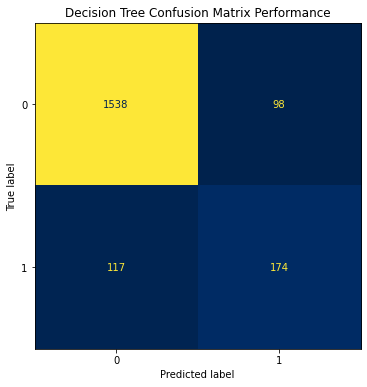

In [52]:
#dt confusion matrix

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Provided values
y_true = np.array([0]*1636 + [1]*291)  # True labels (balanced to match support)
y_pred = np.array([0]*1538 + [1]*98 + [0]*117 + [1]*174)  # Predicted labels (balanced to match precision and recall)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display the confusion matrix with colorblind-friendly colors
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap='cividis', colorbar=False)
plt.title("Decision Tree Confusion Matrix Performance")
plt.show()


Fitting 10 folds for each of 108 candidates, totalling 1080 fits


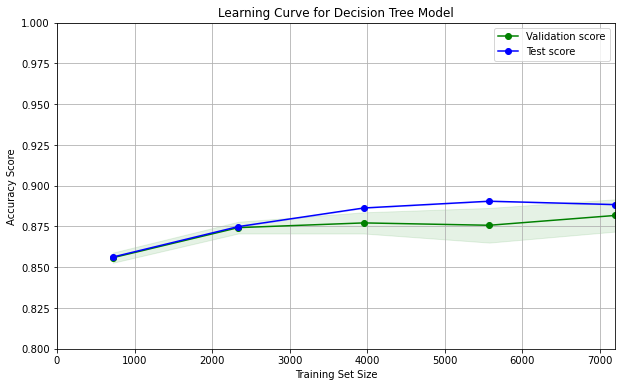

In [53]:
#Graph DT model performance 

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, train_test_split, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Assuming nba_dataset is your DataFrame and has been previously loaded and preprocessed

# Encoding categorical columns
label_encoders = {}
categorical_columns = ['Names', 'Country', 'College', 'Draft_round', 'Draft_number']
for col in categorical_columns:
    le = LabelEncoder()
    nba_dataset[col] = le.fit_transform(nba_dataset[col].astype(str))
    label_encoders[col] = le

# Handling missing values
imputer = SimpleImputer(strategy='mean')
nba_dataset[categorical_columns + ['Age', 'Player_height', 'Player_weight', 'ast', 'net_rating', 'pts', 'usg_pct', 'reb']] = imputer.fit_transform(nba_dataset[categorical_columns + ['Age', 'Player_height', 'Player_weight', 'ast', 'net_rating', 'pts', 'usg_pct', 'reb']])

# Splitting the data into features and target
X = nba_dataset[['Age', 'Player_height', 'Player_weight', 'College', 'Draft_round', 'ast', 'net_rating', 'pts', 'Draft_number', 'usg_pct', 'reb']]
y = nba_dataset['selected yes or no']

# Splitting the dataset into training (70%), validation (15%), and testing (15%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)  # 70% training, 30% temp
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 15% validation, 15% test

# Setting up parameters grid for grid search
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

# Creating the Decision Tree model
decision_tree = DecisionTreeClassifier(random_state=42)

# Setting up the GridSearchCV with k-fold cross-validation (k=10)
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(decision_tree, param_grid, cv=kf, scoring='accuracy', n_jobs=-1, verbose=1)

# Training the model using grid search on the validation set
grid_search.fit(X_val, y_val)

# Best model
best_tree = grid_search.best_estimator_

# Define training sizes and perform learning curve analysis with best parameters
train_sizes, _, validation_scores = learning_curve(
    estimator=best_tree,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=StratifiedKFold(n_splits=5),
    scoring='accuracy'
)

# Calculate mean and standard deviation for validation set scores
validation_mean = np.mean(validation_scores, axis=1)
validation_std = np.std(validation_scores, axis=1)

# Calculate test scores for each training size
test_scores = []
for train_size in train_sizes:
    best_tree.fit(X_train[:train_size], y_train[:train_size])
    test_scores.append(best_tree.score(X_test, y_test))

test_mean = np.array(test_scores)
test_std = np.zeros_like(test_mean)  # Assuming no std deviation for test set scores

# Plot the learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, validation_mean, 'o-', color="g", label="Validation score")
plt.plot(train_sizes, test_mean, 'o-', color="b", label="Test score")

plt.fill_between(train_sizes, validation_mean - validation_std, validation_mean + validation_std, color="g", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="b", alpha=0.1)

plt.title("Learning Curve for Decision Tree Model")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.ylim(0.80, 1.0)  # Adjust y-axis to start from 0.80
plt.xlim(0, max(train_sizes))  # Adjust x-axis to improve visualization
plt.show()

## 4. Importancia de variables

El Random Forest permite estudiar qué variables contribuyen con mayor peso a la predicción.


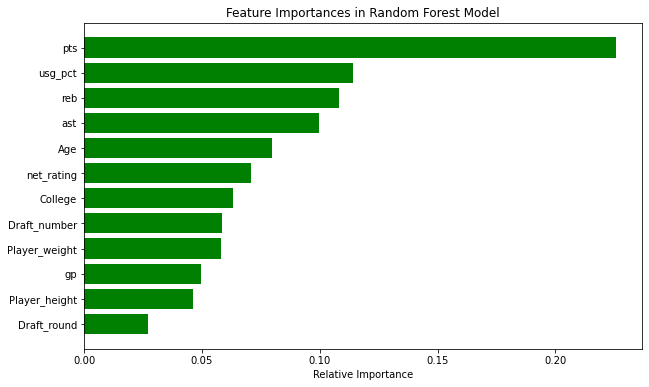

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Assuming 'nba_data' is prepared and encoded for categorical variables

# Define features and target
X = nba_dataset[['Age', 'Player_height', 'gp', 'Player_weight', 'College', 'Draft_round', 'ast', 'net_rating', 'pts', 'Draft_number', 'usg_pct', 'reb']]
y = nba_dataset['selected yes or no']

# Creating the Random Forest model
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model
random_forest.fit(X, y)

# Get feature importances
importances = random_forest.feature_importances_
feature_names = X.columns

# Create a DataFrame to visualize feature importances
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='g')
plt.xlabel('Relative Importance')
plt.title('Feature Importances in Random Forest Model')
plt.gca().invert_yaxis()  # Invert axis to have the most important at the top
plt.show()


## 5. Análisis estadístico de discrepancias

Además de predecir, el proyecto estudia los casos en los que la predicción del modelo y la selección
observada no coinciden. Se aplican pruebas estadísticas sobre variables numéricas y categóricas,
incluyendo corrección de Bonferroni.


In [63]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Sample data loading and preparation
# Assume 'nba_data' is your DataFrame and already includes the 'selected yes or no' column
# You need to make sure all the predictor columns are also included in your DataFrame

# Encoding categorical variables
label_encoders = {}
categorical_columns = ['College', 'Draft_round', 'Draft_number']
for col in categorical_columns:
    le = LabelEncoder()
    nba_dataset[col] = le.fit_transform(nba_dataset[col].astype(str))
    label_encoders[col] = le

# Splitting the data into features and target
X = nba_dataset[['Player_height', 'Player_weight', 'College', 'gp', 'Draft_round', 'ast', 'net_rating', 'pts', 'Draft_number', 'usg_pct', 'reb']]
y = nba_dataset['selected yes or no']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Setting up 10-Fold Cross-Validation
kfold = KFold(10, shuffle=True, random_state=42)

# Creating the Random Forest model
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

# Training the model
random_forest.fit(X_train, y_train)

# Predicting the test set results
y_pred = random_forest.predict(X_test)

# Evaluating the model
# Performing cross-validation
scores = cross_val_score(random_forest, X, y, scoring='accuracy', cv=kfold)
print(f"Accuracy of the model: {accuracy:.2f}")
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

TN, FP, FN, TP = cm.ravel()
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f"Sensitivity (Recall): {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")

print(f'Accuracy scores for each fold are: {scores}')
print(f'Mean accuracy without: {mean(scores):.2f}')
print(f'Standard deviation of accuracy: {std(scores):.2f}')

Accuracy of the model: 0.90
Confusion Matrix:
[[3190   63]
 [ 222  379]]
Sensitivity (Recall): 0.63
Specificity: 0.98
Accuracy scores for each fold are: [0.93385214 0.92140078 0.93307393 0.92217899 0.92523364 0.92367601
 0.92601246 0.91900312 0.92445483 0.9182243 ]
Mean accuracy without: 0.92
Standard deviation of accuracy: 0.00


In [64]:
# Creating a mask for incorrect predictions
incorrect_mask = y_pred != y_test

# Subsetting the test data and labels to find the incorrect predictions
incorrect_predictions = X_test[incorrect_mask]
incorrect_actuals = y_test[incorrect_mask]

# Optionally, reverse encoding the categorical columns to make them more interpretable
for col in categorical_columns:
    le = label_encoders[col]
    incorrect_predictions[col] = le.inverse_transform(incorrect_predictions[col].astype(int))

# Combine the features with the actual and predicted labels for easier analysis
incorrect_predictions['Actual'] = incorrect_actuals
incorrect_predictions['Predicted'] = y_pred[incorrect_mask]

# Display the resulting DataFrame of incorrect instances
pd.DataFrame(incorrect_predictions)


<ipython-input-64-4cb629f3be1a>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  incorrect_predictions[col] = le.inverse_transform(incorrect_predictions[col].astype(int))
<ipython-input-64-4cb629f3be1a>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  incorrect_predictions[col] = le.inverse_transform(incorrect_predictions[col].astype(int))
<ipython-input-64-4cb629f3be1a>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

,Player_height,Player_weight,College,gp,Draft_round,ast,net_rating,pts,Draft_number,usg_pct,reb,Actual,Predicted
6427,200.66,99.790240,79,82,1,1.8,-7.7,17.2,47,0.232,3.8,1,0
9749,198.12,99.790240,76,58,1,1.2,-3.3,5.4,12,0.144,2.6,1,0
10912,208.28,120.201880,117,69,1,0.7,5.9,7.5,69,0.146,7.3,1,0
12513,213.36,113.398000,114,67,1,1.7,0.0,18.0,69,0.231,10.0,0,1
10657,190.50,88.450440,239,59,1,5.2,-5.7,10.9,38,0.192,2.4,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1834,200.66,111.583632,5,76,1,3.0,-8.4,11.9,29,0.217,3.9,1,0
8055,200.66,106.594120,219,75,1,2.4,2.2,13.5,21,0.226,4.6,1,0
11240,190.50,88.450440,239,55,1,2.4,2.8,6.7,38,0.174,1.6,1,0
12596,205.74,108.862080,336,63,1,3.0,7.8,9.8,46,0.119,6.2,1,0


In [65]:
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency

# Load your dataset
# incorrect_predictions = pd.read_csv('path_to_incorrect_predictions.csv')

# Define a column in your dataset that marks the predictions as correct or incorrect
# For example, let's assume 'Actual' is the true label and 'Predicted' is the model's prediction

# First, you need to define these masks properly based on your prediction and actual outcome columns:
true_positives = incorrect_predictions[(incorrect_predictions['Actual'] == 1) & (incorrect_predictions['Predicted'] == 1)]
false_positives = incorrect_predictions[(incorrect_predictions['Actual'] == 0) & (incorrect_predictions['Predicted'] == 1)]
true_negatives = incorrect_predictions[(incorrect_predictions['Actual'] == 0) & (incorrect_predictions['Predicted'] == 0)]
false_negatives = incorrect_predictions[(incorrect_predictions['Actual'] == 1) & (incorrect_predictions['Predicted'] == 0)]

# List of features to test
features_numeric = ['Player_height', 'Player_weight', 'ast', 'net_rating', 'pts', 'usg_pct', 'reb']
features_categorical = ['College', 'Draft_round', 'Draft_number']

# Analyzing numerical features for TP vs FP (adjust as needed for TN vs FN or other comparisons)
print("Numerical Features Analysis for TP vs FP:")
for feature in features_numeric:
    # Check for empty data
    if true_positives[feature].empty or false_positives[feature].empty:
        print(f"{feature}: One of the groups is empty, cannot perform test.")
    else:
        # Assuming data is not normally distributed, using Mann-Whitney U Test
        stat, p = mannwhitneyu(true_positives[feature], false_positives[feature])
        print(f"{feature}: Mann-Whitney U test p-value = {p:.3f}")

# Analyzing categorical features for TP vs FP
print("\nCategorical Features Analysis for TP vs FP:")
for feature in features_categorical:
    # Creating contingency table
    table = pd.crosstab(incorrect_predictions['Actual'], incorrect_predictions[feature])
    stat, p, dof, expected = chi2_contingency(table)
    print(f"{feature}: Chi-square test p-value = {p:.3f}")


Numerical Features Analysis for TP vs FP:
Player_height: One of the groups is empty, cannot perform test.
Player_weight: One of the groups is empty, cannot perform test.
ast: One of the groups is empty, cannot perform test.
net_rating: One of the groups is empty, cannot perform test.
pts: One of the groups is empty, cannot perform test.
usg_pct: One of the groups is empty, cannot perform test.
reb: One of the groups is empty, cannot perform test.

Categorical Features Analysis for TP vs FP:
College: Chi-square test p-value = 0.001
Draft_round: Chi-square test p-value = 0.404
Draft_number: Chi-square test p-value = 0.015


In [67]:
import pandas as pd
from scipy.stats import mannwhitneyu, chi2_contingency

# Load your dataset
# incorrect_predictions = pd.read_csv('path_to_incorrect_predictions.csv')

# Define your subsets for True Negatives and False Negatives
true_negatives = incorrect_predictions[(incorrect_predictions['Actual'] == 0) & (incorrect_predictions['Predicted'] == 0)]
false_negatives = incorrect_predictions[(incorrect_predictions['Actual'] == 1) & (incorrect_predictions['Predicted'] == 0)]

# List of features to test
features_numeric = ['Player_height', 'Player_weight', 'ast', 'net_rating', 'pts', 'usg_pct', 'reb']
features_categorical = ['College', 'Draft_round', 'Draft_number']

# Analyzing numerical features for TN vs FN
print("Numerical Features Analysis for TN vs FN:")
for feature in features_numeric:
    # Check for empty data
    if true_negatives[feature].empty or false_negatives[feature].empty:
        print(f"{feature}: One of the groups is empty, cannot perform test.")
    else:
        # Assuming data is not normally distributed, using Mann-Whitney U Test
        stat, p = mannwhitneyu(true_negatives[feature], false_negatives[feature])
        print(f"{feature}: Mann-Whitney U test p-value = {p:.3f}")

# Analyzing categorical features for TN vs FN
print("\nCategorical Features Analysis for TN vs FN:")
for feature in features_categorical:
    # Creating contingency table
    table = pd.crosstab(incorrect_predictions['Actual'], incorrect_predictions[feature])
    stat, p, dof, expected = chi2_contingency(table)
    print(f"{feature}: Chi-square test p-value = {p:.3f}")


Numerical Features Analysis for TN vs FN:
Player_height: One of the groups is empty, cannot perform test.
Player_weight: One of the groups is empty, cannot perform test.
ast: One of the groups is empty, cannot perform test.
net_rating: One of the groups is empty, cannot perform test.
pts: One of the groups is empty, cannot perform test.
usg_pct: One of the groups is empty, cannot perform test.
reb: One of the groups is empty, cannot perform test.

Categorical Features Analysis for TN vs FN:


College: Chi-square test p-value = 0.001
Draft_round: Chi-square test p-value = 0.404
Draft_number: Chi-square test p-value = 0.015


In [69]:
import pandas as pd
from scipy.stats import chi2_contingency

# Load your dataset
# incorrect_predictions = pd.read_csv('path_to_incorrect_predictions.csv')

# Define your subsets for True Negatives and False Negatives
true_negatives = incorrect_predictions[(incorrect_predictions['Actual'] == 0) & (incorrect_predictions['Predicted'] == 0)]
false_negatives = incorrect_predictions[(incorrect_predictions['Actual'] == 1) & (incorrect_predictions['Predicted'] == 0)]

# List of categorical features to test
features_categorical = ['College', 'Draft_round', 'Draft_number']

# Bonferroni correction
num_tests = len(features_categorical)
alpha = 0.05
corrected_alpha = alpha / num_tests

# Analyzing categorical features for TN vs FN
print("Categorical Features Analysis for TN vs FN:")
for feature in features_categorical:
    # Creating contingency table
    table = pd.crosstab(incorrect_predictions['Actual'], incorrect_predictions[feature])
    stat, p, dof, expected = chi2_contingency(table)
    
    # Applying Bonferroni correction
    corrected_p = p * num_tests
    
    # Print the results
    print(f"{feature}: Chi-square test p-value = {p:.3f}, Bonferroni corrected p-value = {corrected_p:.3f}")
    if corrected_p < corrected_alpha:
        print(f"The result for {feature} is statistically significant after Bonferroni correction.")
    else:
        print(f"The result for {feature} is not statistically significant after Bonferroni correction.")


Categorical Features Analysis for TN vs FN:
College: Chi-square test p-value = 0.001, Bonferroni corrected p-value = 0.004
The result for College is statistically significant after Bonferroni correction.
Draft_round: Chi-square test p-value = 0.404, Bonferroni corrected p-value = 1.213
The result for Draft_round is not statistically significant after Bonferroni correction.
Draft_number: Chi-square test p-value = 0.015, Bonferroni corrected p-value = 0.044
The result for Draft_number is not statistically significant after Bonferroni correction.


## 6. Conclusión

El proyecto combina construcción de datos, Machine Learning y estadística para estudiar tanto la
capacidad predictiva como las discrepancias entre rendimiento observado y decisiones de selección.

Para resultados, discusión metodológica y limitaciones completas, consultar la tesis incluida en el repositorio.
